#Time Series Analysis

Goal: Handle data where "when" it happened matters (Sales, Stock, Sensor logs).

Creating a Time-Aware DataFrame

In [4]:
import pandas as pd
import numpy as np

# Generate 100 days of dates and some random 'Sales' data
dates = pd.date_range(start='2024-01-01', periods=100)
sales = np.random.randint(50, 200, size=100)

df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.set_index('Date', inplace=True) # Essential: Time must be the Index

print(df.head())

            Sales
Date             
2024-01-01    100
2024-01-02    108
2024-01-03     92
2024-01-04    148
2024-01-05     89


#Resampling & Moving Averages

Concept: If daily data is too "noisy" (zig-zaggy), we smooth it out.

In [5]:
# 1. Resample: Change Daily data to Weekly Mean
weekly_sales = df['Sales'].resample('W').mean()

# 2. Rolling: Create a 7-day 'Trend Line' (Moving Average)
df['7D_Trend'] = df['Sales'].rolling(window=7).mean()

print("Weekly Averages:\n", weekly_sales.head())

Weekly Averages:
 Date
2024-01-07    106.285714
2024-01-14    106.285714
2024-01-21    135.714286
2024-01-28    142.142857
2024-02-04    134.000000
Freq: W-SUN, Name: Sales, dtype: float64


#Simple Plot

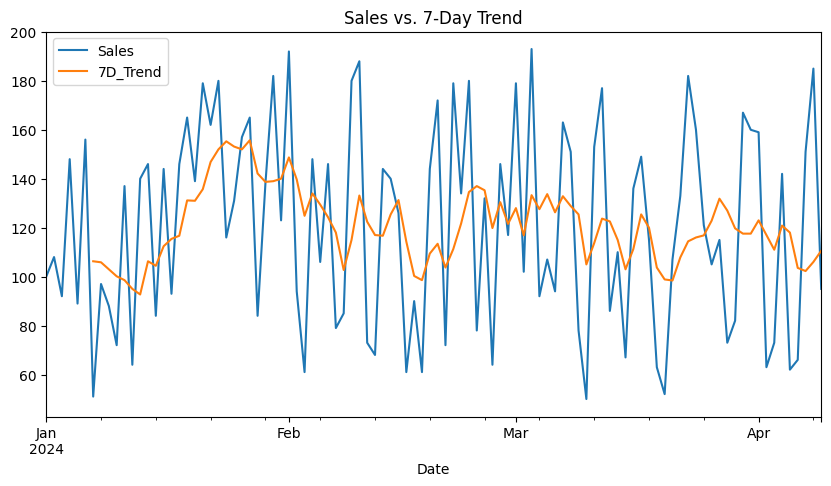

In [6]:
import matplotlib.pyplot as plt

df[['Sales', '7D_Trend']].plot(figsize=(10, 5), title="Sales vs. 7-Day Trend")
plt.show()